# Example 3.6: Monte Carlo simulation of stochastic time series with a given auto-spectral density

In this example, we generate realisations of a stationary stochastic process from a one-sided auto spectral density. Two methods are shown:

- Method 1: Direct summation of cosine waves
- Method 2: The inverse real fast Fourier transform (`irfft`)

We normally choose the simulation duration $T$ and time step $\Delta t$ first. These determine the number of time samples,

$$N=\frac{T}{\Delta t}.$$

In this example, we select $T$ and $\Delta t$ such that $N$ is odd. This gives a full frequency axis that is exactly symmetric about zero. It is therefore wise to round $N$ to an odd number.

## Auto spectral density

The example uses the following one-sided spectrum for wave elevation in the North Sea:

$$
S_X(\omega)=\alpha g^2\omega^{-5}
\exp\left[-\frac{5}{4}\left(\frac{\omega_p}{\omega}\right)^4\right].
$$

Here, $g=9.81\ \mathrm{m/s^2}$, $\alpha=8.1\cdot10^{-3}$ and $\omega_p=0.6\ \mathrm{rad/s}$ is the spectral peak angular frequency. The chosen value corresponds to a dominant wave period of around $10.5\ \mathrm{s}$.

N = 54003
T = 10800.600 s, dt = 0.200 s
Nonnegative-frequency points = 27002
domega = 0.0006 rad/s
omega_max = 15.7077 rad/s


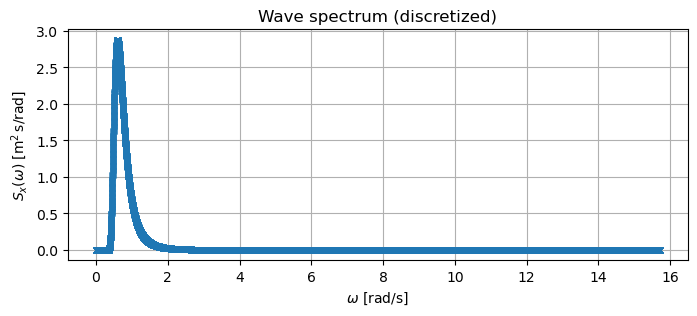

In [26]:
import numpy as np
from matplotlib import pyplot as plt
import time

# 1) Choose the simulation duration and time step
T_requested = 3*3600.21  # Requested duration [s]
dt = 0.2            # Time step [s]
N = int(T_requested / dt)

assert N % 2 == 1, 'Select T and dt such that N is odd in this example'
T = N * dt          # Simulation period
t = np.arange(N) * dt # Time vector

print(f'N = {N}')
print(f'T = {T:.3f} s, dt = {dt:.3f} s')

# 2) Construct the one-sided frequency axis manually
# For odd N, the one-sided axis has (N+1)/2 non-negative frequencies.
domega = 2 * np.pi / T
n_freq = (N + 1) // 2
omega = np.arange(n_freq) * domega
omega_max = omega[-1]          # Largest frequency on the simulation grid

print(f'Nonnegative-frequency points = {n_freq}')
print(f'domega = {domega:.4f} rad/s')
print(f'omega_max = {omega_max:.4f} rad/s')

# 3) Define the one-sided auto-spectral density on this frequency grid
g = 9.81
alpha = 8.1e-3
omega_p = 0.6  # Spectral peak angular frequency [rad/s]

Sx = np.zeros_like(omega)
positive = omega > 0
Sx[positive] = (alpha * g**2 * omega[positive]**-5
                * np.exp(-5/4 * (omega_p/omega[positive])**4))
Sx[0] = 0.0  # Zero DC coefficient for a zero-mean process

plt.figure(figsize=(8, 3))
plt.plot(omega, Sx, marker='x', markersize=5)
plt.title('Wave spectrum (discretized)')
plt.ylabel(r'$S_x(\omega)$ [$\mathrm{m^2\,s/rad}$]')
plt.xlabel(r'$\omega$ [rad/s]')
plt.grid()


## Method 1: Sum of cosine terms

A realisation can be generated by summing cosine waves over the nonnegative frequencies:

$$
x(t_n)=\sum_{k=0}^{(N-1)/2} A_k\cos(\omega_k t_n+\phi_k),
\qquad
A_k=\sqrt{2S_X(\omega_k)\Delta\omega},
$$

where each phase angle is drawn independently from a uniform distribution between $0$ and $2\pi$:

$$\phi_k\sim U(0,2\pi).$$

The sum includes zero frequency and all positive frequencies; each cosine at a positive frequency combines the corresponding positive- and negative-frequency components. The zero-frequency term vanishes here because $A_0=0$. For odd $N$, the one-sided frequency vector, including $\omega=0$, contains $(N+1)/2$ points.

The selected $T$ and $\Delta t$ control the discretisation:

$$
\Delta\omega=\frac{2\pi}{T},
\qquad
\omega_{\max}=\frac{N-1}{2}\Delta\omega.
$$

Thus, a longer duration gives finer frequency resolution, while a smaller time step permits a larger $\omega_{\max}$.

For the one-sided PSD convention used in this course,

$$
\sigma_X^2=\int_0^\infty S_X(\omega)\,d\omega
\approx\sum_k S_X(\omega_k)\Delta\omega.
$$


Spent time = 17698.92 ms


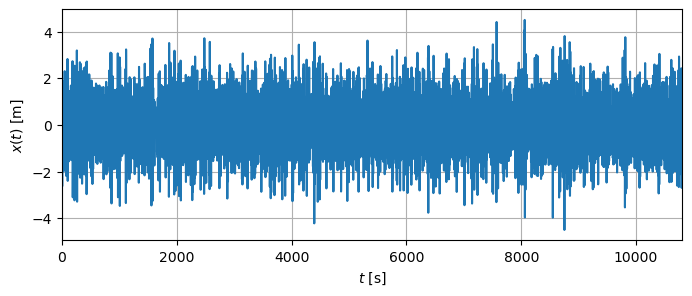

In [27]:
# Physical amplitudes of the cosine components
Ak = np.sqrt(2 * Sx * domega)
Ak[0] = 0.0

phi = np.random.uniform(0, 2*np.pi, n_freq)  # Random phase angles from 0 to 2*pi

t0 = time.time()
x_method1 = np.zeros_like(t)
for k in range(n_freq):  # Include zero frequency (Ak[0] = 0) and positive frequencies
    x_method1 += Ak[k] * np.cos(omega[k] * t + phi[k])
t1 = time.time()

print(f'Spent time = {(t1-t0)*1000:.2f} ms')

plt.figure(figsize=(8, 3))
plt.plot(t, x_method1)
plt.ylabel(r'$x(t)$ [m]')
plt.xlabel(r'$t$ [s]')
plt.xlim(0, T)
plt.grid()


The realisation looks irregular even though it is assembled from deterministic cosine waves. The randomness comes from the independently sampled phase angles. Try changing $T$ or $\Delta t$ and observe how the frequency resolution, maximum represented frequency and simulated time series change.

The individual harmonic contributions can also be inspected directly.


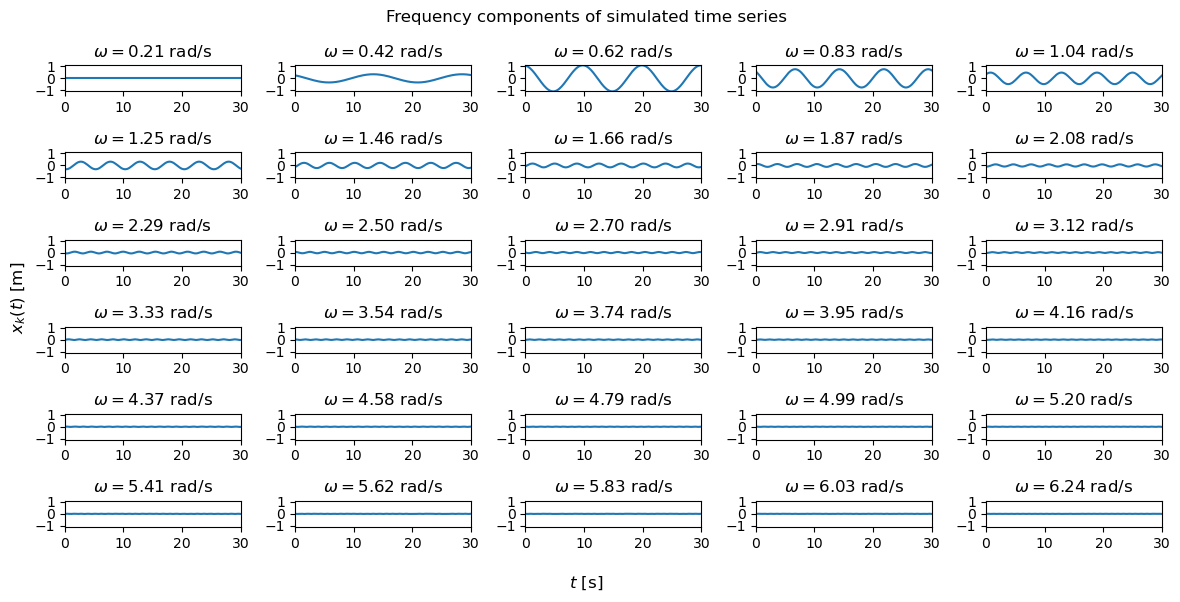

In [16]:
# Plot the first 30 positive-frequency contributions
n_plot = min(30, n_freq - 1)
fig, axs = plt.subplots(6, 5, figsize=(12, 6))
fig.suptitle('Frequency components of simulated time series')

for ax, k in zip(axs.flat, range(1, n_plot + 1)):
    ax.plot(t, Ak[k] * np.cos(omega[k] * t + phi[k]))
    ax.set_title(r'$\omega=$' + f'{omega[k]:.2f} rad/s')
    ax.set_xlim(0, np.max(t))
    ax.set_ylim(np.max(Ak) * np.array([-1.0, 1.0]))

for ax in axs.flat[n_plot:]:
    ax.axis('off')

fig.supxlabel(r'$t$ [s]')
fig.supylabel(r'$x_k(t)$ [m]')
plt.tight_layout()


The lowest-frequency cosine waves contribute little because this spectrum contains little energy there. The largest contributions occur around the spectral peak. Notice also that the cosine waves have different phase angles: some begin near a peak, others near a trough, and so on.


## Method 2: The inverse real fast Fourier transform (IRFFT)

The same sum can be evaluated much more efficiently with an FFT algorithm. `irfft` is the inverse FFT specialized for a real-valued output. It accepts the nonnegative-frequency coefficients and automatically supplies the conjugate negative-frequency part required for a real time series.

Starting with the cosine sum from Method 1 and using $\cos(\theta)=\operatorname{real}(e^{i\theta})$ gives

$$
x(t_n)=\sum_{k=0}^{(N-1)/2}A_k\cos(\omega_k t_n+\phi_k)
=\operatorname{real}\left(\sum_{k=0}^{(N-1)/2}A_k e^{i\phi_k}e^{i\omega_k t_n}\right).
$$

Since $\omega_k=k\Delta\omega$, $t_n=n\Delta t$ and $\Delta\omega\Delta t=2\pi/N$, we obtain

$$
x_n=\operatorname{real}\left(\sum_{k=0}^{(N-1)/2}A_k e^{i\phi_k}e^{i2\pi kn/N}\right).
$$

The exponential $e^{i2\pi kn/N}$ is the kernel of the inverse DFT. In the complete frequency representation, each cosine is divided between a positive-frequency coefficient and its complex-conjugate negative-frequency coefficient.

The course defines the DFT pair with the factor $1/N$ in the forward transform:

$$
X_k=\frac{1}{N}\sum_{n=0}^{N-1}x_n e^{-i2\pi kn/N},
\qquad
x_n=\sum_{k=0}^{N-1}X_k e^{i2\pi kn/N}.
$$

A cosine with amplitude $A_k$ and phase $\phi_k$ therefore has the positive-frequency course coefficient

$$
X_k=\frac{A_k}{2}e^{i\phi_k}.
$$

NumPy uses the opposite normalization: its forward FFT has no $1/N$, while its inverse FFT contains $1/N$. We therefore multiply the result returned by `irfft` by $N$:

$$
x_n=N\operatorname{IRFFT}(X_k).
$$

The factor $N$ outside the IRFFT is the natural conversion from the DFT convention used in the course to NumPy's convention.


Spent time = 12.25 ms


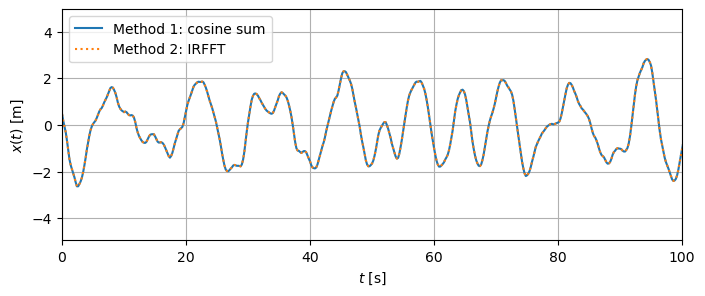

In [29]:
t0 = time.time()

#phi = np.random.uniform(0, 2*np.pi, n_freq)  # Optional: draw new phase angles

# Nonnegative-frequency coefficients using the course DFT convention
Xk = (Ak / 2) * np.exp(1j * phi)
Xk[0] = 0.0

# irfft automatically supplies the conjugate negative-frequency coefficients
# and returns exactly N real-valued time samples. The factor N converts
# NumPy's inverse-transform normalization to the course DFT convention.
x_method2 = N * np.fft.irfft(Xk, n=N)
t1 = time.time()

print(f'Spent time = {(t1-t0)*1000:.2f} ms')

plt.figure(figsize=(8, 3))
plt.plot(t, x_method1, label='Method 1: cosine sum')
plt.plot(t, x_method2, label='Method 2: IRFFT', linestyle=':')
plt.ylabel(r'$x(t)$ [m]')
plt.xlabel(r'$t$ [s]')
plt.xlim(0, 100)
plt.grid()
plt.legend()


The two time series are equal because the two methods use the same amplitudes and phase angles. The IRFFT method is preferred for long simulations because it evaluates the sum much faster.

## Validation of the process variance

The area under the one-sided auto-spectral density gives the theoretical variance:

$$
\sigma_X=\sqrt{\int_0^\infty S_X(\omega)\,d\omega}
\approx\sqrt{\sum_k S_X(\omega_k)\Delta\omega}.
$$

Because the simulated record contains complete periods of the discrete harmonic components, its time-domain standard deviation should agree closely with the discretized spectral result.


In [8]:
# The discretized spectral area gives the expected variance.
sigma_spectrum = np.sqrt(np.sum(Ak**2) / 2)
sigma_method1 = np.std(x_method1)
sigma_method2 = np.std(x_method2)

print(f'Spectral standard deviation = {sigma_spectrum:.5f} m')
print(f'Method 1 standard deviation = {sigma_method1:.5f} m')
print(f'Method 2 standard deviation = {sigma_method2:.5f} m')


Spectral standard deviation = 1.13029 m
Method 1 standard deviation = 1.13029 m
Method 2 standard deviation = 1.13029 m
